In [1]:
import math
import dataclasses
import functools
import numpy
import matplotlib.pyplot as plt
from hypothesis import given, strategies as st
from collections.abc import Callable
from abc import ABC, abstractmethod

# Algorithm Implementation

In [2]:
def dbg(v):
    print(repr(v))
    return v


def samples_per_bit(sample_rate: int, freq: int, num_periods: int) -> int:
    return num_periods * sample_rate // freq


def bin(sample_rate: int, frequency: int, window_size: int) -> int:
    return int(round((frequency * window_size) / sample_rate))


assert [bin(9600, f, 32) for f in [1200, 2400]] == [4, 8]


@given(st.integers(4800, 44100))
def test_bin_integer_division(s: int):
    """
    Test for integer division errors
    """
    f = 2400
    c = 8
    N = samples_per_bit(s, f, c)
    k = bin(s, f, N)
    assert k == math.floor(0.5 + ((N * f) / s)), f"expected: {k2}, got: {k=}"


test_bin_integer_division()

In [3]:
def dB(p: float, p_0: float) -> float:
    return 10 * math.log10(p / p_0)


@dataclasses.dataclass(slots=True)
class Spec:
    sample_rate: int
    mark_frequency: int
    space_frequency: int

    @classmethod
    def with_kcs(cls) -> "Spec":
        return cls(9600, 2400, 1200)


@dataclasses.dataclass(frozen=True)
class DftTerm:
    frequency: int
    w_real: float
    w_imag: float
    d1: float
    d2: float

    def power(self) -> float:
        return math.pow(self.d2, 2) + math.pow(self.d1, 2) - self.w_real * self.d1 * self.d2


@dataclasses.dataclass(frozen=True)
class Output:
    mark: DftTerm
    space: DftTerm


def _goertzel_inner_loop(state: (float, float), sample: int, *, w_real: float = float("nan")) -> (float, float):
    (d1, d2) = state
    y = sample + w_real * d1 - d2
    return (y, d1)


def goertzel_single_term(sample_rate: int, frequency: int, data: list[int]) -> DftTerm:
    window_size = len(data)
    k = bin(sample_rate, frequency, window_size)
    wt = 2 * math.pi * k / window_size
    w_real = 2 * math.cos(wt)
    w_imag = math.sin(wt)

    (d1, d2) = functools.reduce(
        functools.partial(_goertzel_inner_loop, w_real=w_real), 
        data, 
        (0, 0),
    )

    return DftTerm(
        frequency,
        w_real,
        w_imag,
        d1,
        d2,
    )

    
def goertzel(spec: Spec, data: list[int]) -> Output:
    return Output(
        goertzel_single_term(spec.sample_rate, spec.mark_frequency, data),
        goertzel_single_term(spec.sample_rate, spec.space_frequency, data),
    )


def hamming(window_size: int):
    alpha = 25 / 46
    beta = 1 - alpha
    return (alpha - beta * math.cos(math.tau * t / (window_size - 1)) for t in range(0, window_size))


def snr(s: numpy.ndarray, n: numpy.ndarray) -> float:
    p_s = numpy.mean(s**2)
    p_n = numpy.mean((2*n)**2)
    snr_val = 10 * numpy.log10(p_s / p_n)
    return snr_val

# Input Signal Implementation

In [4]:
class Signal(ABC):
    @abstractmethod
    def build(self) -> numpy.ndarray:
        pass


@dataclasses.dataclass(frozen=True, slots=True)
class Time(Signal):
    sample_rate: int
    t_max: float = 1
    window: slice = slice(None, None, None)

    def build(self) -> numpy.ndarray:
        return numpy.arange(0, self.t_max, 1 / self.sample_rate)[self.window]


@dataclasses.dataclass(frozen=True, slots=True)
class Sine(Signal):
    t: numpy.ndarray
    frequency: float
    amplitude: float = 1

    def build(self) -> numpy.ndarray:
        return self.amplitude * numpy.sin(2 * numpy.pi * self.frequency * self.t)


@dataclasses.dataclass(frozen=True, slots=True)
class Cnse(Signal):
    t: numpy.ndarray
    scale: float = 1
    decay: float = 0.05

    def build(self) -> numpy.ndarray:
        len_t = len(self.t)
        nse = numpy.random.randn(len_t)
        kernel = numpy.exp(-self.t / self.decay)
        cnse_val = numpy.convolve(nse, kernel)
        return (self.scale * cnse_val)[:len_t]

# Experimentation

In [5]:
def apply_wow_flutter(audio, sr, wow_percent, wow_rate, flutter_percent, flutter_rate):
    x = audio.astype(np.float32)
    n = len(x)
    t = np.arange(n) / sr

    a_w = wow_percent / 100.0
    a_f = flutter_percent / 100.0

    wow = a_w * np.sin(2 * np.pi * wow_rate * t)
    flutter = a_f * np.sin(2 * np.pi * flutter_rate * t)

    r = 1.0 + wow + flutter
    tau = np.cumsum(1.0 / r)
    tau = tau * (1.0 / sr)
    tau -= tau[0]
    tau *= (n - 1) / tau[-1]

    warped = np.interp(np.arange(n), tau, x).astype(np.float32)
    return warped

# Input Signal Spectrum

## Visualization Code

In [6]:
def plot_spectrum(sample_rate: int, t: numpy.ndarray, s: numpy.ndarray):
    fig = plt.figure(figsize=(7, 7), layout='constrained')
    axs = fig.subplot_mosaic([["signal", "signal"],
                              ["magnitude", "log_magnitude"],
                              ["phase", "angle"]])
    
    # plot time signal:
    axs["signal"].set_title("Signal")
    axs["signal"].plot(t, s, color='C0')
    axs["signal"].set_xlabel("Time (s)")
    axs["signal"].set_ylabel("Amplitude")
    
    # plot different spectrum types:
    axs["magnitude"].set_title("Magnitude Spectrum")
    axs["magnitude"].magnitude_spectrum(s, Fs=spec.sample_rate, color='C1')
    
    axs["log_magnitude"].set_title("Log. Magnitude Spectrum")
    axs["log_magnitude"].magnitude_spectrum(s, Fs=spec.sample_rate, scale='dB', color='C1')
    
    axs["phase"].set_title("Phase Spectrum ")
    axs["phase"].phase_spectrum(s, Fs=spec.sample_rate, color='C2')
    
    axs["angle"].set_title("Angle Spectrum")
    axs["angle"].angle_spectrum(s, Fs=spec.sample_rate, color='C2')

## For a Noiseless Signal

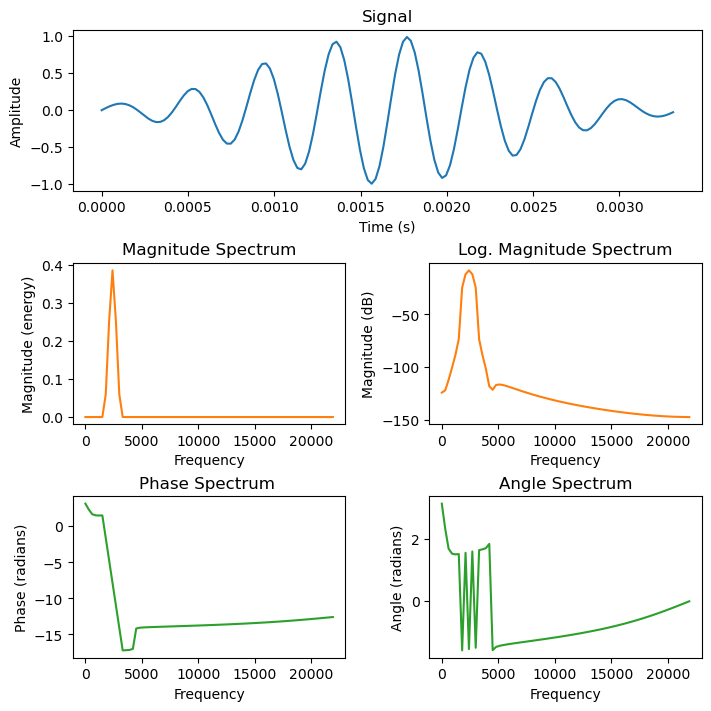

In [7]:
spec = Spec.with_kcs()
spec.sample_rate = 44100
t = Time(spec.sample_rate, window=slice(samples_per_bit(spec.sample_rate, spec.mark_frequency, 8))).build()
s = Sine(t, spec.mark_frequency).build()
plot_spectrum(spec.sample_rate, t, s * numpy.hamming(len(t)))

## For a Noisy Signal

SNR=-3.1828342500930122 dB


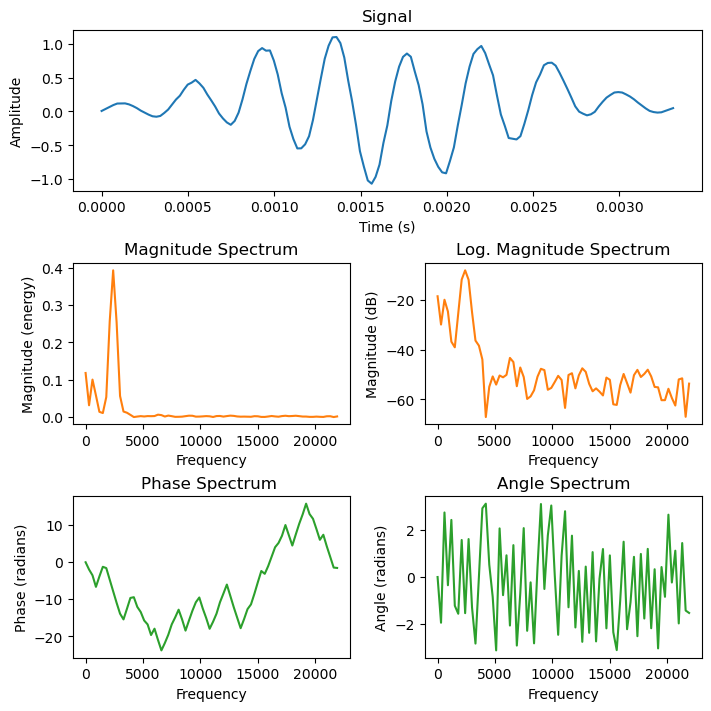

In [8]:
numpy.random.seed(0)
spec = Spec.with_kcs()
spec.sample_rate = 44100
t = Time(spec.sample_rate, window=slice(samples_per_bit(spec.sample_rate, spec.mark_frequency, 8))).build()
s = Sine(t, spec.mark_frequency).build()
n = Cnse(t, scale=0.05, decay=0.05).build()
print(f"SNR={snr(s, n)} dB")
plot_spectrum(spec.sample_rate, t, (s + n) * numpy.hamming(len(t)))

# Goertzel Algorithm Response Spectrum

## Visualization Code

In [9]:
def plot_power_spectrum(window: str, spec: Spec, t: numpy.ndarray, freqs: numpy.ndarray, signal_fun: Callable[[float, int], numpy.ndarray]):
    window_size = len(t)
    vlines = [spec.mark_frequency, spec.space_frequency]   
    data = [signal_fun(t, f) for f in freqs]
    output = [goertzel(spec, d) for d in data]
    mark_power = numpy.array([o.mark.power() for o in output])
    space_power = numpy.array([o.space.power() for o in output])

    match window:
        case 'hamming': window_val = numpy.hamming(window_size)
        case 'custom': window_val = numpy.array(list(hamming(window_size)))
        case _: window_val = 1
    windowed_data = [d * window_val for d in data]
    windowed_output = [goertzel(spec, d) for d in windowed_data]
    windowed_mark_power = numpy.array([o.mark.power() for o in windowed_output])
    windowed_space_power = numpy.array([o.space.power() for o in windowed_output])

    fig = plt.figure(figsize=(12, 6), dpi=100, layout='constrained')
    axs = fig.subplot_mosaic([
        ['power', 'windowed_power'],
        ['rel_power', 'rel_windowed_power'],
    ])
    axs['power'].plot(freqs, mark_power)
    axs['power'].plot(freqs, space_power)
    axs['power'].set_title('Goertzel Power Spectrum')
    axs['power'].set_xlabel('frequency (Hz)')
    axs['power'].set_ylabel('power')
    axs['power'].set_yscale('log')
    axs['power'].set_ylim(bottom=1e-1)
    axs['power'].vlines(vlines, 0, 1, transform=axs['power'].get_xaxis_transform(), colors='c', linestyles='dotted')

    axs['windowed_power'].plot(freqs, windowed_mark_power)
    axs['windowed_power'].plot(freqs, windowed_space_power)
    axs['windowed_power'].set_title(f'Goertzel Power Spectrum ({window=})')
    axs['windowed_power'].set_xlabel('frequency (Hz)')
    axs['windowed_power'].set_ylabel('power')
    axs['windowed_power'].set_yscale('log')
    axs['windowed_power'].set_ylim(bottom=1e-1)
    axs['windowed_power'].vlines(vlines, 0, 1, transform=axs['windowed_power'].get_xaxis_transform(), colors='c', linestyles='dotted')
    
    axs['rel_power'].plot(
        freqs, 
        numpy.array([dB(o.mark.power(), o.space.power()) for o in output]),
    )
    axs['rel_power'].set_title('Goertzel Power Spectrum (dB)')
    axs['rel_power'].set_xlabel('frequency (Hz)')
    axs['rel_power'].set_ylabel('$dB_{mark~vs.~space}$')
    axs['rel_power'].vlines(vlines, 0, 1, transform=axs['rel_power'].get_xaxis_transform(), colors='c', linestyles='dotted')
       
    axs['rel_windowed_power'].plot(
        freqs, 
        numpy.array([dB(o.mark.power(), o.space.power()) for o in windowed_output]),
    )
    axs['rel_windowed_power'].set_title(f'Goertzel Power Spectrum (dB; {window=})')
    axs['rel_windowed_power'].set_xlabel('frequency (Hz)')
    axs['rel_windowed_power'].set_ylabel('$dB_{mark~vs.~space}$')
    axs['rel_windowed_power'].vlines(vlines, 0, 1, transform=axs['rel_windowed_power'].get_xaxis_transform(), colors='c', linestyles='dotted')

## For a Noiseless Signal

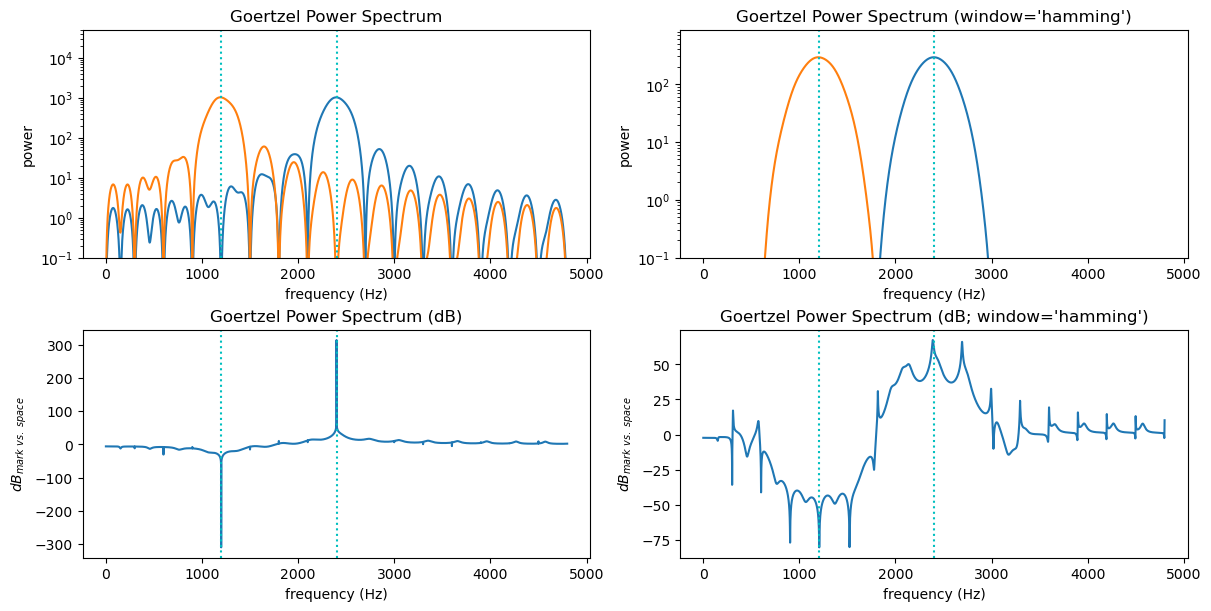

In [10]:
spec = Spec.with_kcs()
spec.sample_rate *= 2
time = Time(spec.sample_rate, window=slice(samples_per_bit(spec.sample_rate, spec.mark_frequency, 8))).build()
freqs = numpy.arange(1, 4800)
plot_power_spectrum('hamming', spec, time, freqs, lambda t, f: Sine(t, f).build())

## For a Noisy Signal

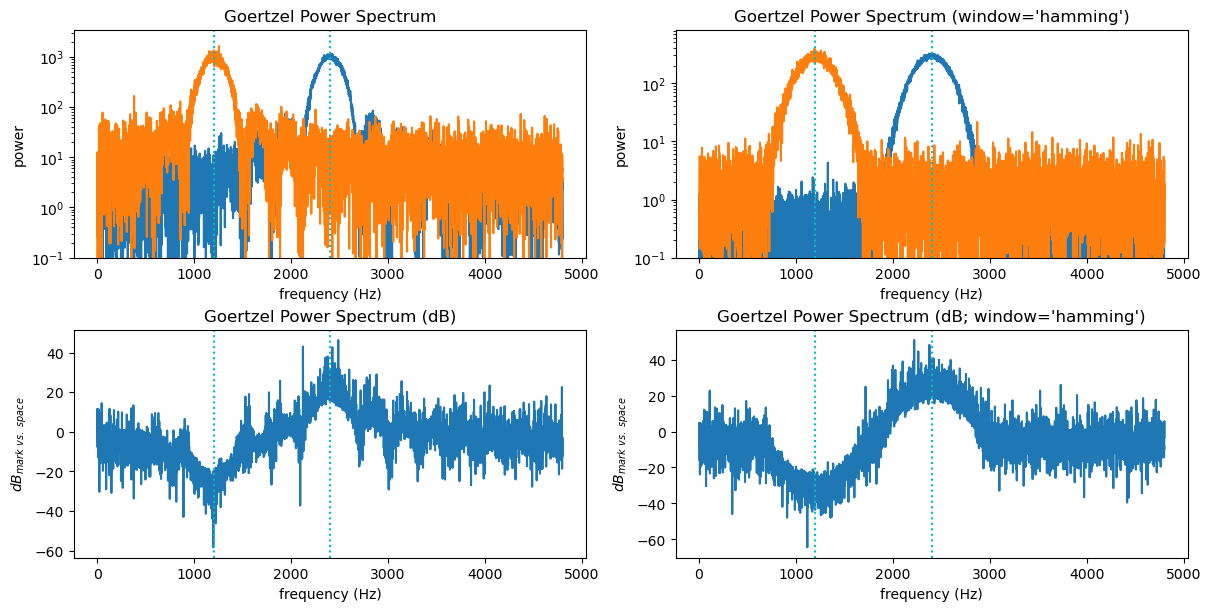

In [11]:
numpy.random.seed(0)
spec = Spec.with_kcs()
spec.sample_rate = 19200
time = Time(spec.sample_rate, window=slice(samples_per_bit(spec.sample_rate, spec.mark_frequency, 8))).build()
freqs = numpy.arange(1, 4800)
plot_power_spectrum('hamming', spec, time, freqs, lambda t, f: Sine(t, f).build() + Cnse(t, scale=0.1, decay=0.05).build())